In [1]:
import pandas as pd

df = pd.read_csv('Campaign-Data.csv')

print("--- Data Info ---")
print(df.info())
print("\n--- Head ---")
print(df.head())
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2976 entries, 0 to 2975
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Client ID              2976 non-null   object 
 1   Client Type            2976 non-null   object 
 2   Number of Customers    2976 non-null   int64  
 3   Montly Target          2976 non-null   int64  
 4   Zip Code               2976 non-null   int64  
 5   Calendardate           2976 non-null   object 
 6   Amount Collected       2976 non-null   int64  
 7   Unit Sold              2976 non-null   int64  
 8   Campaign (Email)       2976 non-null   float64
 9   Campaign (Flyer)       2976 non-null   float64
 10  Campaign (Phone)       2976 non-null   float64
 11  Sales Contact 1        2976 non-null   float64
 12  Sales Contact 2        2976 non-null   float64
 13  Sales Contact 3        2976 non-null   float64
 14  Sales Contact 4        2976 non-null  

Success: Data structure is secure and valid.
 Model R2 Score: 0.66
--- Final visualizations generated with updated 'hue' logic ---


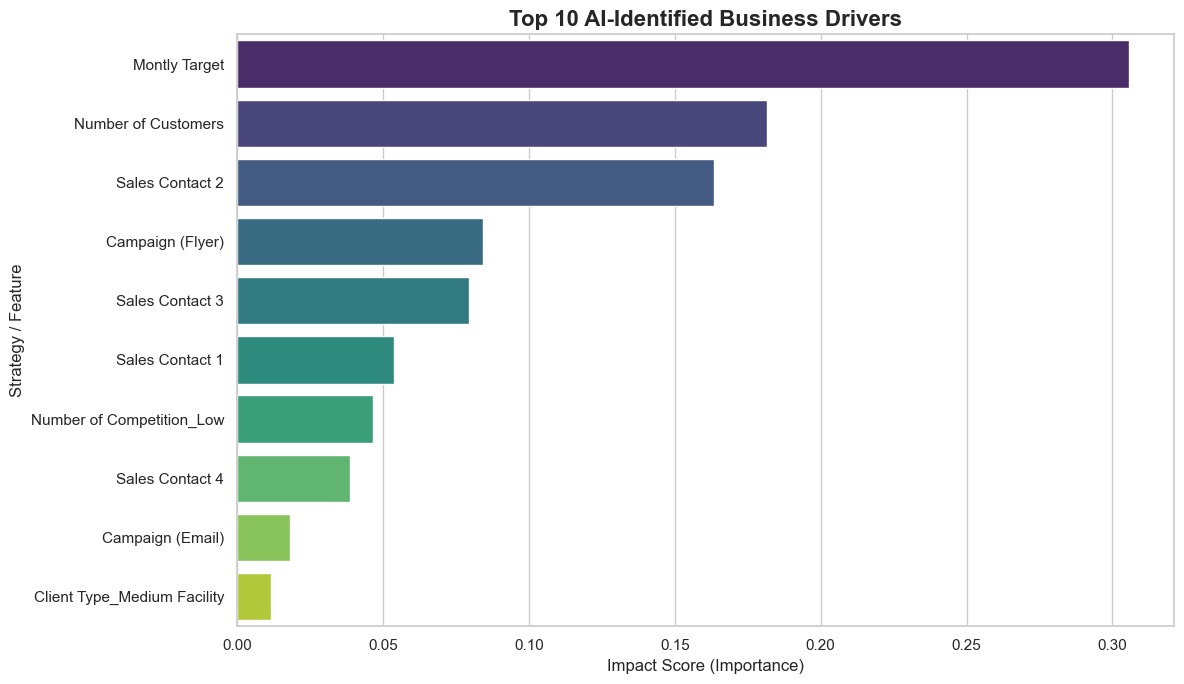

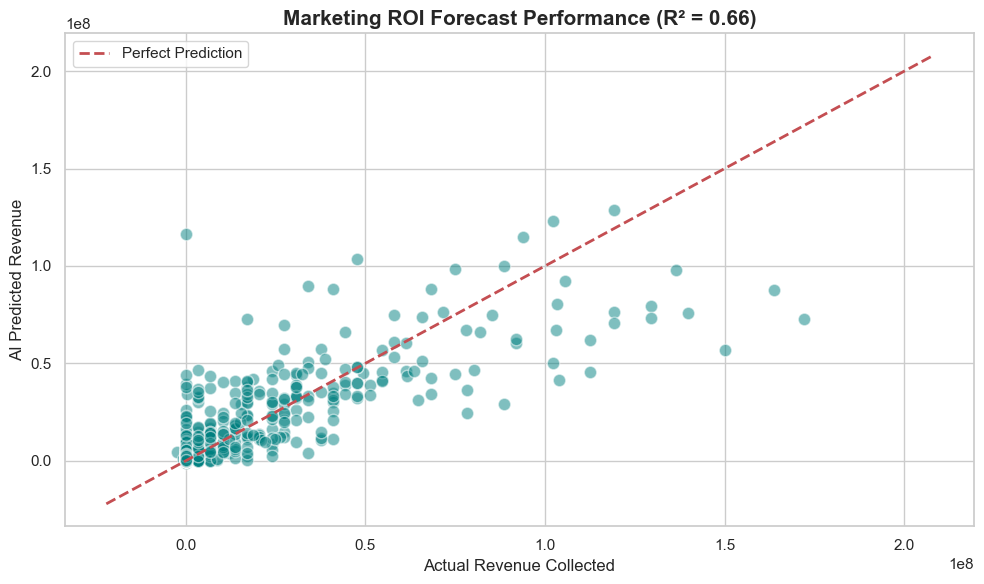

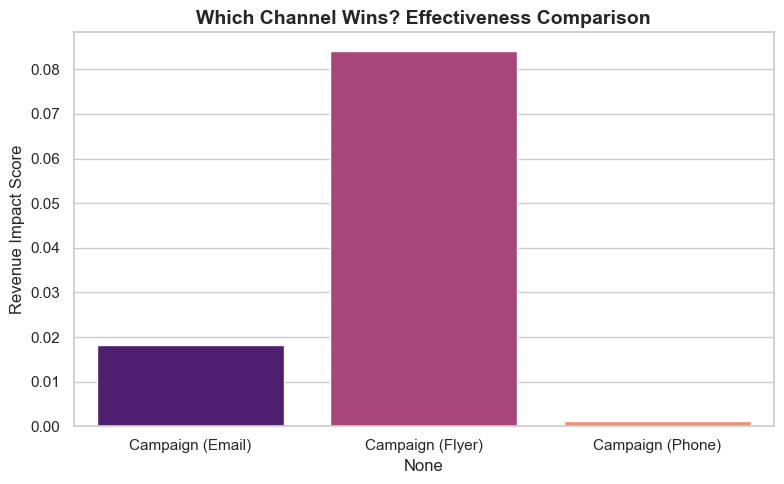

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

def validate_marketing_csv(data):
    required_cols = ['Amount Collected', 'Campaign (Email)', 'Campaign (Flyer)', 'Campaign (Phone)']
    if not all(col in data.columns for col in required_cols):
        return False, "Validation Error: Missing required marketing columns."
    if data['Amount Collected'].isnull().any():
        return False, "Validation Error: Target column contains null values."
    return True, "Success: Data structure is secure and valid."
    
df = pd.read_csv('Campaign-Data.csv')
status, message = validate_marketing_csv(df)
print(message)

if status:
    cols_to_drop = ['Client ID', 'Calendardate']
    df_clean = df.drop(columns=cols_to_drop)

    df_clean = pd.get_dummies(df_clean, columns=['Client Type', 'Number of Competition'], drop_first=True)

    df_clean = df_clean.fillna(0)

    # Model Training
    X = df_clean.drop(columns=['Amount Collected', 'Unit Sold'])
    y = df_clean['Amount Collected']
    features = X.columns
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestRegressor(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    print(f" Model R2 Score: {score:.2f}")

    # 5. Visualizations with corrected 'hue' logic
    sns.set_theme(style="whitegrid")

    # A. Top 10 Drivers Plot
    plt.figure(figsize=(12, 7))
    importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False).head(10)
    # Using 'hue' to match the y-axis variable to fix Seaborn warning and look cool
    ax1 = sns.barplot(x=importances.values, y=importances.index, hue=importances.index, palette='viridis')
    if ax1.get_legend(): ax1.get_legend().remove() # Remove legend if it exists
    plt.title('Top 10 AI-Identified Business Drivers', fontsize=16, fontweight='bold')
    plt.xlabel('Impact Score (Importance)')
    plt.ylabel('Strategy / Feature')
    plt.tight_layout()
    plt.savefig('performance_drivers_cool.png')

    # B. Actual vs Predicted ROI Plot
    plt.figure(figsize=(10, 6))
    plt.scatter(y_test, y_pred, alpha=0.5, color='teal', edgecolor='w', s=80)
    plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')
    plt.title(f'Marketing ROI Forecast Performance (R² = {score:.2f})', fontsize=15, fontweight='bold')
    plt.xlabel('Actual Revenue Collected')
    plt.ylabel('AI Predicted Revenue')
    plt.legend()
    plt.tight_layout()
    plt.savefig('roi_prediction_accuracy.png')

    # C. Campaign Channel Effectiveness Analysis
    campaign_cols = ['Campaign (Email)', 'Campaign (Flyer)', 'Campaign (Phone)']
    existing_campaigns = [c for c in campaign_cols if c in X.columns]
    campaign_impact = pd.Series(model.feature_importances_[X.columns.isin(existing_campaigns)], index=existing_campaigns)

    plt.figure(figsize=(8, 5))
    ax2 = sns.barplot(x=campaign_impact.index, y=campaign_impact.values, hue=campaign_impact.index, palette='magma')
    if ax2.get_legend(): ax2.get_legend().remove()
    plt.title('Which Channel Wins? Effectiveness Comparison', fontsize=14, fontweight='bold')
    plt.ylabel('Revenue Impact Score')
    plt.tight_layout()
    plt.savefig('campaign_channel_battle.png')

    print("--- Final visualizations generated with updated 'hue' logic ---")


